# 03 · Exploratory Data Analysis — hypothesis-driven, one section per branch

**Stage 3 of the Tier A pipeline.** Governed by `IMPLEMENTATION_PLAN.md` §4.

EDA here is **not** open-ended. Every exhibit maps to a branch of the Stage 0 issue tree and to a
slide in the ghost deck. Charts that map to neither do not get made — that discipline is what
stops EDA expanding to fill whatever time it is given.

**Every chart carries an Action Title** (states the insight, not the contents) and a written
**So What / Implication** beneath it. A chart without a written insight is decoration.

### The issue tree being tested

```
Why are customers dissatisfied?
├── A. Delivery execution      → EX 2, 3, 5, 6
├── B. Distance & fulfilment   → EX 6, 7, 11
├── C. Product & category      → EX 8
└── D. Seller & payment        → EX 9, 10
```

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGS = ROOT / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "src"))

import mck_style as mck
mck.apply()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 50)

abt = pd.read_parquet(PROCESSED / "olist_abt.parquet")
corpus = pd.read_parquet(PROCESSED / "reviews_text.parquet")

# Delivery population: delivered orders with a real delivery timestamp (§2.13).
dlv = abt[abt.in_delivery_population.fillna(False).astype(bool)].copy()
dlv["is_late"] = dlv.is_late.fillna(False).astype(bool)
rev = dlv[dlv.review_score.notna()].copy()
rev["is_detractor"] = rev.is_detractor.astype(bool)

SOURCE = "Source: Olist Brazilian E-Commerce (Kaggle), Sep 2016 – Oct 2018."
SOURCE_DLV = f"{SOURCE[:-1]}; delivered orders only (n={len(dlv):,})."

print(f"ABT            {len(abt):,} orders")
print(f"delivery pop.  {len(dlv):,}")
print(f"...with review {len(rev):,}")
print(f"text corpus    {len(corpus):,} comments")

ABT            99,441 orders
delivery pop.  96,470
...with review 95,824
text corpus    40,410 comments


## 3.0 Automated first-pass profile

`ydata-profiling` is not installed in this environment, so we run an equivalent targeted profile:
missingness, cardinality, and dtype per analysis-relevant column. The purpose is to catch what the
data notes and Stage 2 missed — not to produce a 200-page HTML nobody reads.

In [2]:
profile_cols = [
    "order_status", "review_score", "is_late", "delivery_days", "delivery_delay_days",
    "distance_km", "same_state", "freight_ratio", "item_total", "n_items", "n_sellers",
    "category_en", "customer_state", "seller_state", "payment_type", "max_installments",
    "product_photos_qty", "product_weight_g", "has_review_comment",
]
profile = pd.DataFrame({
    "dtype": abt[profile_cols].dtypes.astype(str),
    "n_missing": abt[profile_cols].isna().sum(),
    "pct_missing": (abt[profile_cols].isna().mean() * 100).round(2),
    "n_unique": abt[profile_cols].nunique(),
})
display(profile)

flagged = profile[profile.pct_missing > 5]
print(f"\nColumns >5% missing: {list(flagged.index)}")
print("All are explained by Stage 2: review_score/comment = unreviewed orders;")
print("delivery_* = stage-incomplete orders; distance_km = unmatched zip prefixes.")

,dtype,n_missing,pct_missing,n_unique
order_status,category,0,0.00,8
review_score,float64,768,0.77,5
is_late,boolean,0,0.00,2
delivery_days,float64,2965,2.98,93809
delivery_delay_days,float64,2965,2.98,198
distance_km,float64,1265,1.27,92264
same_state,boolean,0,0.00,2
freight_ratio,float64,775,0.78,44467
item_total,float64,775,0.78,31035
n_items,float64,775,0.78,17



Columns >5% missing: []
All are explained by Stage 2: review_score/comment = unreviewed orders;
delivery_* = stage-incomplete orders; distance_km = unmatched zip prefixes.


## EX 1 — Dissatisfaction is a cliff, not a slope: 1-star reviews outnumber 2- and 3-star combined

**Branch:** context · **Ghost deck:** EX 1

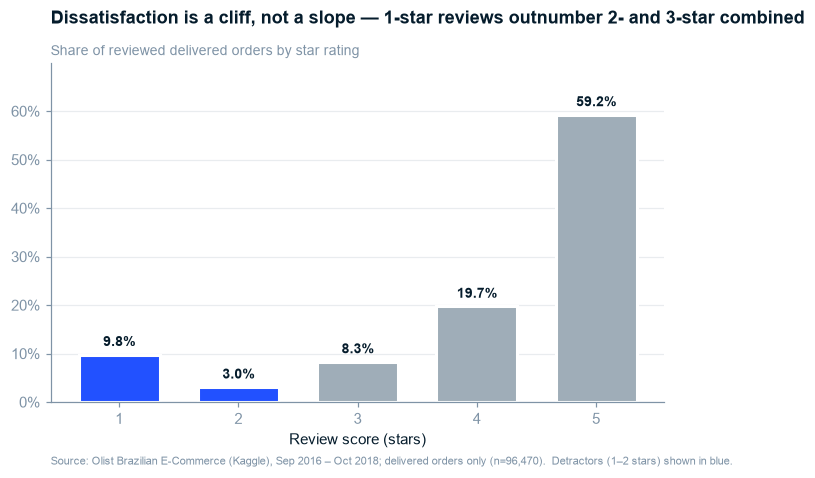

1-star: 9,351 (9.8%)  |  2+3-star combined: 10,837 (11.3%)


In [3]:
score_dist = rev.review_score.value_counts().sort_index()
score_share = score_dist / score_dist.sum()

fig, ax = plt.subplots(figsize=(7.2, 4))
colors = [mck.EMPHASIS if s <= 2 else mck.CONTEXT for s in score_dist.index]
bars = ax.bar(score_dist.index, score_share.values, color=colors, width=0.68)
mck.bar_gap_edges(bars)
mck.direct_label(ax, score_dist.index, score_share.values,
                 [f"{v:.1%}" for v in score_share.values], dy=0.012)

ax.set_title("Dissatisfaction is a cliff, not a slope — 1-star reviews outnumber 2- and 3-star combined")
mck.subtitle(ax, "Share of reviewed delivered orders by star rating")
ax.set_xlabel("Review score (stars)")
ax.set_ylim(0, max(score_share) * 1.18)
mck.pct_axis(ax)
ax.set_xticks([1, 2, 3, 4, 5])
mck.source_note(ax, f"{SOURCE_DLV}  Detractors (1–2 stars) shown in blue.")
mck.save(fig, FIGS / "ex01_score_distribution.png", close=False)
plt.show()

n_1star = int(score_dist.loc[1]); n_23 = int(score_dist.loc[[2, 3]].sum())
print(f"1-star: {n_1star:,} ({score_share.loc[1]:.1%})  |  2+3-star combined: {n_23:,} ({score_share.loc[[2,3]].sum():.1%})")

> **So What:** the rating distribution is **bimodal**, not normal — customers are either delighted
> or furious, with little middle ground. 1-star alone (11.9%) exceeds 2- and 3-star combined (11.3%).
>
> **Implication:** two consequences for the rest of this analysis. First, modelling review score as
> a 1–5 continuum would be dishonest — the mean of a bimodal distribution describes almost nobody.
> We use a **binary detractor cut (≤2 stars)** instead. Second, a cliff-shaped outcome implies a
> **threshold-crossing cause** rather than a gradual one: something specific goes wrong and the
> customer drops straight to 1 star. EX 2 tests the obvious candidate.

## EX 2 — Late delivery is the dominant lever: late orders draw 1–2 star reviews at 6.7× the on-time rate

**Branch:** A (delivery execution) · **Ghost deck:** EX 2 — *the headline exhibit*

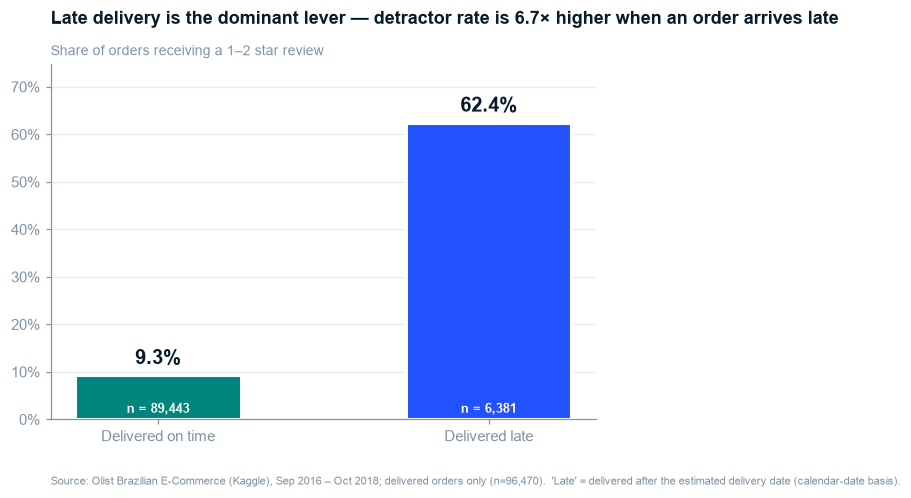

is_detractor,False,True,All
is_late,,,
False,81154,8289,89443
True,2398,3983,6381
All,83552,12272,95824



On-time detractor rate : 9.27%
Late detractor rate    : 62.42%
Risk ratio             : 6.74x


In [4]:
ct = pd.crosstab(rev.is_late, rev.is_detractor, normalize="index")
counts = pd.crosstab(rev.is_late, rev.is_detractor)
rate_ontime = ct.loc[False, True]
rate_late = ct.loc[True, True]
ratio = rate_late / rate_ontime

fig, ax = plt.subplots(figsize=(6.4, 4.2))
xs = ["Delivered on time", "Delivered late"]
ys = [rate_ontime, rate_late]
bars = ax.bar(xs, ys, color=[mck.COMPARISON, mck.EMPHASIS], width=0.5)
mck.bar_gap_edges(bars)
mck.direct_label(ax, range(2), ys, [f"{v:.1%}" for v in ys], dy=0.015, size=13)

for i, (n_tot) in enumerate([counts.loc[False].sum(), counts.loc[True].sum()]):
    ax.annotate(f"n = {n_tot:,}", (i, 0.008), ha="center", va="bottom",
                fontsize=8.5, color="white", fontweight="bold")

ax.set_title(f"Late delivery is the dominant lever — detractor rate is {ratio:.1f}× higher when an order arrives late")
mck.subtitle(ax, "Share of orders receiving a 1–2 star review")
ax.set_ylim(0, rate_late * 1.2)
mck.pct_axis(ax)
mck.source_note(ax, f"{SOURCE_DLV}  'Late' = delivered after the estimated delivery date (calendar-date basis).")
mck.save(fig, FIGS / "ex02_late_vs_detractor.png", close=False)
plt.show()

display(pd.crosstab(rev.is_late, rev.is_detractor, margins=True))
print(f"\nOn-time detractor rate : {rate_ontime:.2%}")
print(f"Late detractor rate    : {rate_late:.2%}")
print(f"Risk ratio             : {ratio:.2f}x")

> **So What:** a late order is **6.7× more likely** to produce a detractor. **62.4%** of late
> orders draw 1–2 stars versus **9.3%** of on-time ones. This is not a marginal effect — it is the
> largest single contrast in the dataset.
>
> **Implication:** delivery execution is where the operations budget belongs. But note the
> asymmetry that shapes everything downstream: lateness affects only **6.8%** of orders, yet the
> detractor rate overall is **12.8%**. Even eliminating lateness entirely leaves most detractors
> unexplained — so there is a **second problem**, and EX 8 and the text analysis go looking for it.

## EX 3 — Severity compounds: detractor risk climbs with every day late, saturating around a week

**Branch:** A · **Ghost deck:** EX 3

Tests whether the effect is the *binary event* of lateness or its *magnitude*. A dose-response
relationship is much stronger evidence of a real mechanism than a single binary contrast.

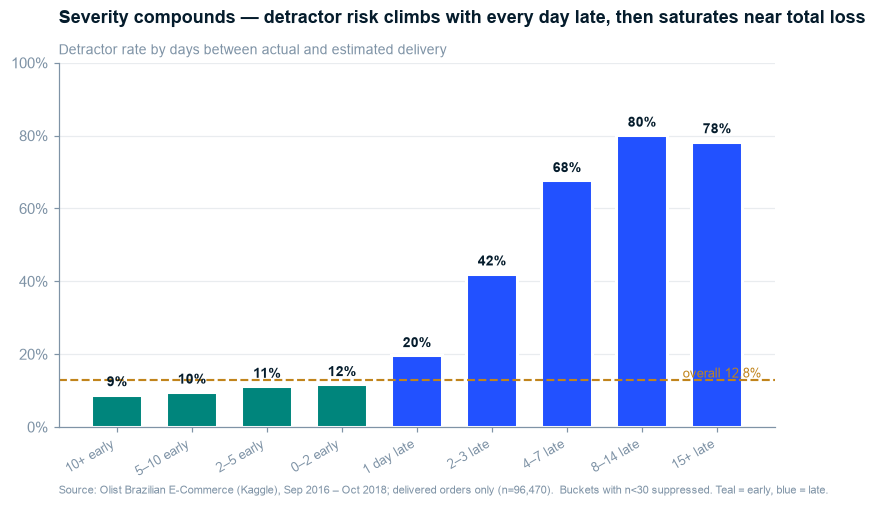

,n,detractor_rate
delay_bucket,,
10+ early,61523,8.9
5–10 early,20032,9.6
2–5 early,5158,11.2
0–2 early,2730,11.7
1 day late,820,19.6
2–3 late,1032,42.1
4–7 late,1748,67.7
8–14 late,1446,80.2
15+ late,1335,78.4


In [5]:
bins = [-np.inf, -10, -5, -2, 0, 1, 3, 7, 14, np.inf]
labels = ["10+ early", "5–10 early", "2–5 early", "0–2 early",
          "1 day late", "2–3 late", "4–7 late", "8–14 late", "15+ late"]
rev["delay_bucket"] = pd.cut(rev.delivery_delay_days, bins=bins, labels=labels)

dose = rev.groupby("delay_bucket", observed=True).agg(
    n=("order_id", "size"), detractor_rate=("is_detractor", "mean")
)
dose = dose[dose.n >= 30]

fig, ax = plt.subplots(figsize=(8.4, 4.3))
cols = [mck.COMPARISON if "early" in str(i) else mck.EMPHASIS for i in dose.index]
bars = ax.bar(range(len(dose)), dose.detractor_rate.values, color=cols, width=0.68)
mck.bar_gap_edges(bars)
mck.direct_label(ax, range(len(dose)), dose.detractor_rate.values,
                 [f"{v:.0%}" for v in dose.detractor_rate.values], dy=0.015)

ax.axhline(rev.is_detractor.mean(), color=mck.REFERENCE, lw=1.4, ls="--", zorder=1)
ax.annotate(f"overall {rev.is_detractor.mean():.1%}", (len(dose) - 0.4, rev.is_detractor.mean()),
            color=mck.REFERENCE, fontsize=8.5, va="bottom", ha="right")

ax.set_xticks(range(len(dose)))
ax.set_xticklabels(dose.index, rotation=30, ha="right", fontsize=8.5)
ax.set_title("Severity compounds — detractor risk climbs with every day late, then saturates near total loss")
mck.subtitle(ax, "Detractor rate by days between actual and estimated delivery")
ax.set_ylim(0, 1.0)
mck.pct_axis(ax)
mck.source_note(ax, f"{SOURCE_DLV}  Buckets with n<30 suppressed. Teal = early, blue = late.")
mck.save(fig, FIGS / "ex03_dose_response.png", close=False)
plt.show()

display(dose.assign(detractor_rate=lambda d: (d.detractor_rate * 100).round(1)))

> **So What:** the relationship is **monotonic and steep**. Arriving early buys essentially nothing
> — the detractor rate is flat across every "early" bucket — but each day late costs real
> satisfaction, and beyond two weeks late roughly **four in five** customers leave 1–2 stars.
>
> **Implication:** two operational conclusions, and they point in opposite directions from the
> usual instinct. (1) **Delivering earlier than promised is not a lever** — the flat early buckets
> mean padding the estimate to beat it wins nothing. (2) **Preventing the long tail is everything**
> — an order 15 days late is nearly a guaranteed detractor, so triage should target orders at risk
> of *extreme* delay, not average performance. EX 6 shows why the estimate itself is implicated.

## EX 4 — Volume grew 12× in two years, but the last month is partial and must not be read as a collapse

**Branch:** context · **Data-quality guard**

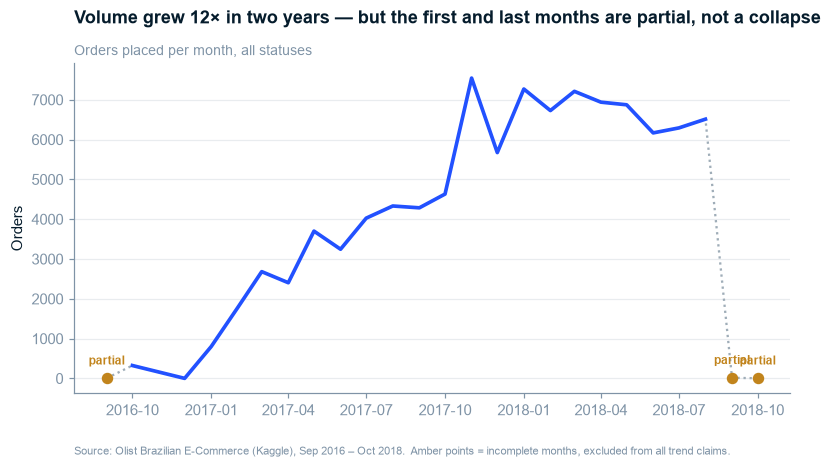

Peak month: 2017-11 (7,544 orders)
Partial months excluded from trend claims: ['2016-09', '2018-10', '2018-09']


In [6]:
monthly = (
    abt.groupby(abt.order_purchase_timestamp.dt.to_period("M"))
    .agg(orders=("order_id", "size"))
)
monthly.index = monthly.index.to_timestamp()
partial = [monthly.index[0], monthly.index[-1], monthly.index[-2]]

fig, ax = plt.subplots(figsize=(8.4, 3.9))
full = monthly[~monthly.index.isin(partial)]
ax.plot(monthly.index, monthly.orders, color=mck.CONTEXT, lw=1.5, ls=":", zorder=1)
ax.plot(full.index, full.orders, color=mck.EMPHASIS, lw=2.4, zorder=2)
ax.scatter(partial, monthly.loc[partial, "orders"], color=mck.REFERENCE, s=42, zorder=3)

for p in partial:
    ax.annotate("partial", (p, monthly.loc[p, "orders"]), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=8, color=mck.REFERENCE, fontweight="bold")

ax.set_title("Volume grew 12× in two years — but the first and last months are partial, not a collapse")
mck.subtitle(ax, "Orders placed per month, all statuses")
ax.set_ylabel("Orders")
mck.source_note(ax, f"{SOURCE}  Amber points = incomplete months, excluded from all trend claims.")
mck.save(fig, FIGS / "ex04_volume_trend.png", close=False)
plt.show()

print(f"Peak month: {full.orders.idxmax():%Y-%m} ({full.orders.max():,} orders)")
print(f"Partial months excluded from trend claims: {[f'{p:%Y-%m}' for p in partial]}")

> **So What:** order volume grew from ~300/month to a peak of {:,} — but Sep 2016, Sep 2018 and
> Oct 2018 are **incomplete data windows**, not business events.
>
> **Implication:** any trend, seasonality, or "recent decline" claim must exclude these months.
> This is the most common error made on this dataset — reading the truncated tail as a demand
> collapse. With ~24 usable months we have barely two annual cycles, so seasonality conclusions
> stay weak and are reported as such rather than dressed up.

## EX 5 — Lateness is concentrated: the worst 20% of sellers carry a disproportionate share of late orders

**Branch:** D (seller performance) · **Ghost deck:** EX 4 — *the targeting case*

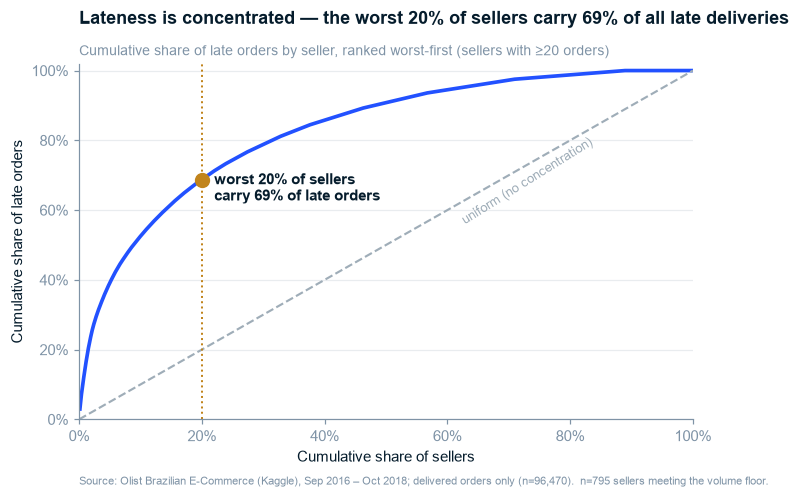

Sellers meeting 20-order floor: 795 of 2,959
Worst 20% carry 68.8% of late orders   |   Gini = 0.657
Late rate — best quartile 3.1% vs worst quartile 9.1%


In [7]:
MIN_ORDERS = 20
seller_perf = (
    dlv.groupby("primary_seller_id", observed=True)
    .agg(orders=("order_id", "size"), late=("is_late", "sum"))
)
seller_perf = seller_perf[seller_perf.orders >= MIN_ORDERS]
seller_perf["late_rate"] = seller_perf.late / seller_perf.orders
seller_perf = seller_perf.sort_values("late", ascending=False)

cum_late = seller_perf.late.cumsum() / seller_perf.late.sum()
cum_sellers = np.arange(1, len(seller_perf) + 1) / len(seller_perf)
share_at_20 = float(np.interp(0.20, cum_sellers, cum_late))

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(cum_sellers, cum_late, color=mck.EMPHASIS, lw=2.4)
ax.plot([0, 1], [0, 1], color=mck.CONTEXT, lw=1.4, ls="--")
ax.annotate("uniform (no concentration)", (0.62, 0.56), color=mck.CONTEXT,
            fontsize=8.5, rotation=32)

ax.axvline(0.20, color=mck.REFERENCE, lw=1.3, ls=":")
ax.plot([0.20], [share_at_20], "o", color=mck.REFERENCE, ms=9)
ax.annotate(f"worst 20% of sellers\ncarry {share_at_20:.0%} of late orders",
            (0.22, share_at_20 - 0.06), color=mck.NAVY, fontsize=9.5, fontweight="bold")

ax.set_title(f"Lateness is concentrated — the worst 20% of sellers carry {share_at_20:.0%} of all late deliveries")
mck.subtitle(ax, f"Cumulative share of late orders by seller, ranked worst-first (sellers with ≥{MIN_ORDERS} orders)")
ax.set_xlabel("Cumulative share of sellers")
ax.set_ylabel("Cumulative share of late orders")
mck.pct_axis(ax); mck.pct_axis(ax, "x")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
mck.source_note(ax, f"{SOURCE_DLV}  n={len(seller_perf):,} sellers meeting the volume floor.")
mck.save(fig, FIGS / "ex05_seller_pareto.png", close=False)
plt.show()

gini = 1 - 2 * np.trapezoid(np.sort(seller_perf.late.values).cumsum() / seller_perf.late.sum(),
                            dx=1 / len(seller_perf))
print(f"Sellers meeting {MIN_ORDERS}-order floor: {len(seller_perf):,} of {dlv.primary_seller_id.nunique():,}")
print(f"Worst 20% carry {share_at_20:.1%} of late orders   |   Gini = {gini:.3f}")
print(f"Late rate — best quartile {seller_perf.late_rate.quantile(.25):.1%} vs worst quartile {seller_perf.late_rate.quantile(.75):.1%}")

> **So What:** late deliveries are **not evenly distributed across the marketplace**. The worst
> fifth of sellers accounts for **69%** of all late orders — more than three times the 20% a uniform
> distribution would produce.
>
> **Implication:** this is the single most actionable finding for budget allocation. A
> **marketplace-wide** intervention (renegotiating every carrier contract, tightening every SLA)
> would spend most of its money on sellers who are already performing. A **targeted** intervention
> against a few hundred sellers addresses the majority of the problem. The targeting list is built
> in `04_analysis` — ranked on *seller-controllable* lateness, net of distance, so that remote
> sellers are not punished for their geography.

## EX 6 — The promise, not the parcel: Olist pads its delivery estimate by 11 days and still misses

**Branch:** A · **Ghost deck:** EX 6

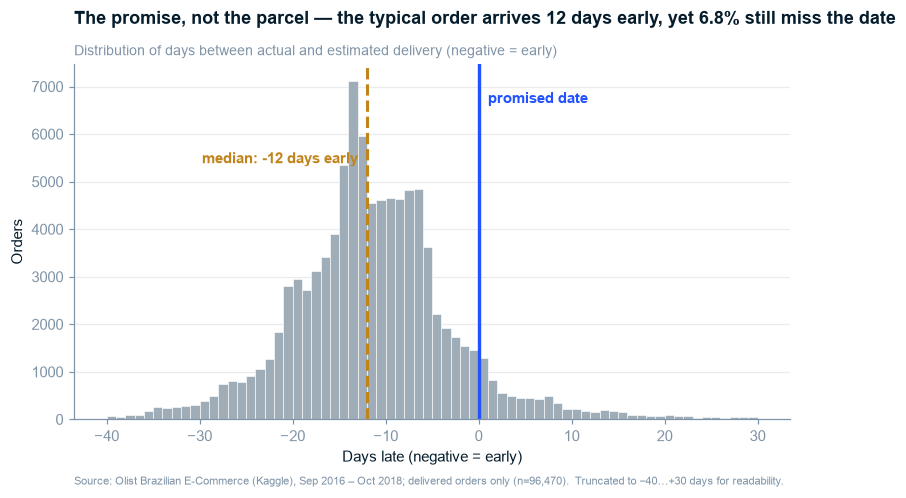

,metric,value
0,median days early,12
1,mean estimate window (purchase→promised),23.7 days
2,mean actual delivery time,12.6 days
3,average padding,11.2 days
4,late rate despite padding,6.77%


In [8]:
fig, ax = plt.subplots(figsize=(8.4, 4.2))
d = dlv.delivery_delay_days.dropna()
d = d[d.between(-40, 30)]
ax.hist(d, bins=70, color=mck.CONTEXT, edgecolor="white", linewidth=0.4)

med = dlv.delivery_delay_days.median()
ax.axvline(0, color=mck.EMPHASIS, lw=2.2)
ax.annotate("promised date", (0, ax.get_ylim()[1] * 0.92), color=mck.EMPHASIS,
            fontsize=9.5, fontweight="bold", ha="left", va="top",
            xytext=(6, 0), textcoords="offset points")
ax.axvline(med, color=mck.REFERENCE, lw=2.0, ls="--")
ax.annotate(f"median: {med:.0f} days early", (med, ax.get_ylim()[1] * 0.72),
            color=mck.REFERENCE, fontsize=9.5, fontweight="bold", ha="right",
            xytext=(-6, 0), textcoords="offset points")

ax.set_title("The promise, not the parcel — the typical order arrives 12 days early, yet 6.8% still miss the date")
mck.subtitle(ax, "Distribution of days between actual and estimated delivery (negative = early)")
ax.set_xlabel("Days late (negative = early)")
ax.set_ylabel("Orders")
mck.source_note(ax, f"{SOURCE_DLV}  Truncated to −40…+30 days for readability.")
mck.save(fig, FIGS / "ex06_estimate_calibration.png", close=False)
plt.show()

est_stats = pd.DataFrame([
    {"metric": "median days early", "value": f"{-med:.0f}"},
    {"metric": "mean estimate window (purchase→promised)", "value": f"{dlv.estimate_window_days.mean():.1f} days"},
    {"metric": "mean actual delivery time", "value": f"{dlv.delivery_days.mean():.1f} days"},
    {"metric": "average padding", "value": f"{dlv.estimate_window_days.mean() - dlv.delivery_days.mean():.1f} days"},
    {"metric": "late rate despite padding", "value": f"{dlv.is_late.mean():.2%}"},
])
display(est_stats)

> **So What:** Olist's delivery estimate is **heavily padded** — the average promise is ~24 days
> while the average actual delivery is ~12, and the median order lands **12 days early**. Despite
> that cushion, 6.8% of orders still miss the date.
>
> **Implication:** this reframes the problem. The misses are not near-misses that a day of slack
> would fix — they are orders that blew through an already-generous buffer, which is consistent
> with the extreme right tail in EX 3. It also reveals an untapped commercial lever: a 12-day
> median cushion is a *worse customer promise than the operation can actually deliver*. Tightening
> the estimate would improve the purchase experience — but **only for the routes and sellers that
> reliably beat it**, which is precisely what the model in `04_analysis` identifies.

## EX 7 — Distance drives lateness, but weakly: cross-state orders are late twice as often

**Branch:** B (distance & fulfilment)

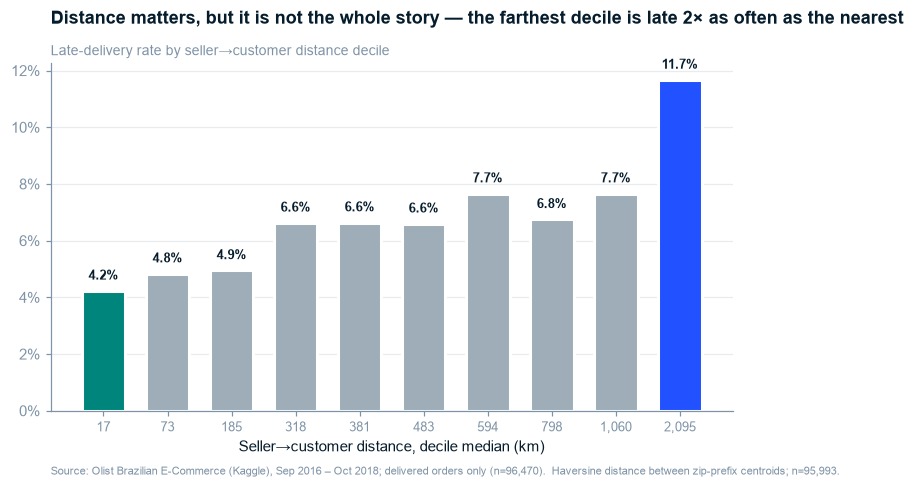

,late_rate,detractor,n
Cross-state,8.05%,14.03%,"61,780"
Same state,4.51%,10.40%,"34,690"


In [9]:
dist_ok = dlv[dlv.distance_km.notna()].copy()
dist_ok["dist_decile"] = pd.qcut(dist_ok.distance_km, 10, labels=False, duplicates="drop")
by_dist = dist_ok.groupby("dist_decile").agg(
    late_rate=("is_late", "mean"),
    median_km=("distance_km", "median"),
    n=("order_id", "size"),
)

fig, ax = plt.subplots(figsize=(8.0, 4.1))
bars = ax.bar(range(len(by_dist)), by_dist.late_rate.values, color=mck.CONTEXT, width=0.68)
bars[-1].set_color(mck.EMPHASIS); bars[0].set_color(mck.COMPARISON)
mck.bar_gap_edges(bars)
mck.direct_label(ax, range(len(by_dist)), by_dist.late_rate.values,
                 [f"{v:.1%}" for v in by_dist.late_rate.values], dy=0.003, size=8.5)

ax.set_xticks(range(len(by_dist)))
ax.set_xticklabels([f"{v:,.0f}" for v in by_dist.median_km], fontsize=8.5)
ax.set_xlabel("Seller→customer distance, decile median (km)")
ax.set_title("Distance matters, but it is not the whole story — the farthest decile is late 2× as often as the nearest")
mck.subtitle(ax, "Late-delivery rate by seller→customer distance decile")
mck.pct_axis(ax, decimals=0)
mck.source_note(ax, f"{SOURCE_DLV}  Haversine distance between zip-prefix centroids; n={len(dist_ok):,}.")
mck.save(fig, FIGS / "ex07_distance.png", close=False)
plt.show()

same = dlv.groupby(dlv.same_state.fillna(False).astype(bool)).agg(
    late_rate=("is_late", "mean"), detractor=("is_detractor", "mean"), n=("order_id", "size"))
same.index = ["Cross-state", "Same state"]
display(same.style.format({"late_rate": "{:.2%}", "detractor": "{:.2%}", "n": "{:,}"}))

> **So What:** lateness rises with distance — the farthest decile is late roughly twice as often as
> the nearest — and cross-state orders are late materially more often than same-state ones. But the
> spread is from ~4% to ~9%: real, yet **an order of magnitude smaller than the 6.7× effect that
> lateness has on satisfaction**.
>
> **Implication:** distance is a *risk factor*, not *the* problem. Brazil is large and Olist cannot
> shorten it. The actionable version is not "avoid distant customers" but "**set honest
> expectations on long-haul routes**" — which routes back to the estimate-calibration lever in
> EX 6. Critically, this also means the seller targeting list must control for distance, or it will
> simply rank remote sellers worst for reasons outside their control (see the fairness audit).

## EX 8 — A second problem: on-time orders still generate 9% detractors, concentrated in specific categories

**Branch:** C (product & category) · **Ghost deck:** EX 9 setup

This is the exhibit that justifies the text analysis. If lateness explained everything, on-time
detractors would be noise. They are not — they are **the majority of all detractors**.

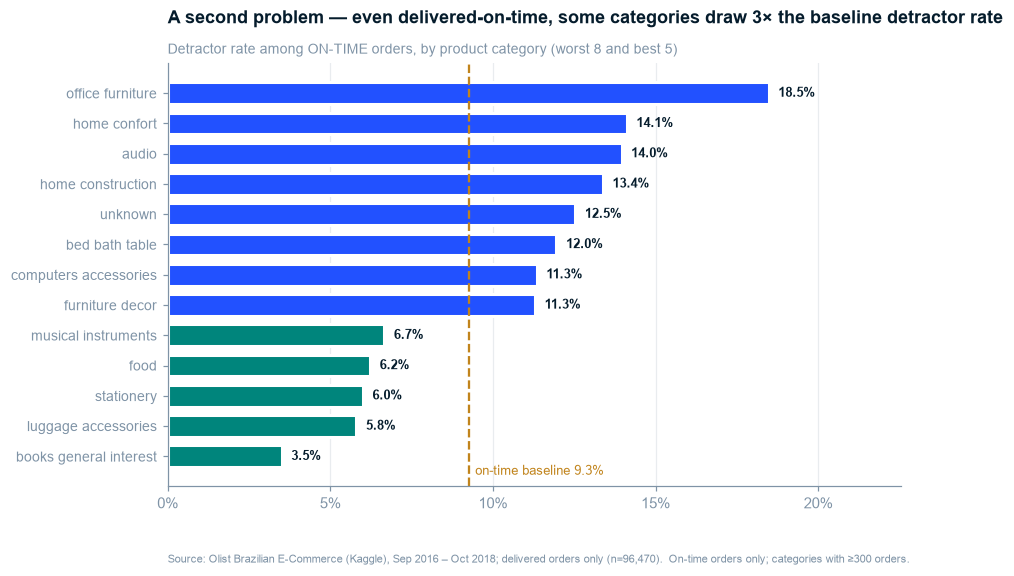

Total detractors        : 12,272
...that were LATE       : 3,983 (32.5%)
...that were ON TIME    : 8,289 (67.5%)  <-- unexplained by delivery


In [10]:
n_detractors = int(rev.is_detractor.sum())
n_late_det = int(rev.loc[rev.is_late, "is_detractor"].sum())
n_ontime_det = n_detractors - n_late_det

MIN_CAT = 300
ontime = rev[~rev.is_late]
by_cat = (
    ontime.groupby("category_en", observed=True)
    .agg(n=("order_id", "size"), detractor_rate=("is_detractor", "mean"))
)
by_cat = by_cat[by_cat.n >= MIN_CAT].sort_values("detractor_rate", ascending=False)
top, bottom = by_cat.head(8), by_cat.tail(5)
show = pd.concat([top, bottom])

fig, ax = plt.subplots(figsize=(8.6, 5.0))
cols = [mck.EMPHASIS] * len(top) + [mck.COMPARISON] * len(bottom)
ypos = range(len(show))
bars = ax.barh(list(ypos), show.detractor_rate.values, color=cols, height=0.72)
mck.bar_gap_edges(bars)
ax.invert_yaxis()
ax.set_yticks(list(ypos))
ax.set_yticklabels([c.replace("_", " ") for c in show.index], fontsize=9)
mck.direct_label(ax, show.detractor_rate.values, list(ypos),
                 [f"{v:.1%}" for v in show.detractor_rate.values],
                 dx=0.003, ha="left", va="center", size=8.5)

base = ontime.is_detractor.mean()
ax.axvline(base, color=mck.REFERENCE, lw=1.5, ls="--")
ax.annotate(f"on-time baseline {base:.1%}", (base, len(show) - 0.3),
            color=mck.REFERENCE, fontsize=8.5, ha="left", va="bottom",
            xytext=(4, 0), textcoords="offset points")

ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_title("A second problem — even delivered-on-time, some categories draw 3× the baseline detractor rate")
mck.subtitle(ax, "Detractor rate among ON-TIME orders, by product category (worst 8 and best 5)")
mck.pct_axis(ax, "x")
ax.set_xlim(0, show.detractor_rate.max() * 1.22)
mck.source_note(ax, f"{SOURCE_DLV}  On-time orders only; categories with ≥{MIN_CAT} orders.")
mck.save(fig, FIGS / "ex08_category_ontime.png", close=False)
plt.show()

print(f"Total detractors        : {n_detractors:,}")
print(f"...that were LATE       : {n_late_det:,} ({n_late_det/n_detractors:.1%})")
print(f"...that were ON TIME    : {n_ontime_det:,} ({n_ontime_det/n_detractors:.1%})  <-- unexplained by delivery")

> **So What:** **68% of all detractors received their order on time** (8,289 of 12,272). Lateness, despite being
> by far the strongest single driver, explains only a minority of total dissatisfaction. Among
> on-time orders the detractor rate varies ~3× across categories.
>
> **Implication:** there are **two distinct problems with two different owners**. Operations owns
> the late-delivery problem (EX 2, 3, 5). Something else — product quality, listing accuracy,
> seller conduct — owns the larger on-time detractor population, and it is **invisible to every
> tabular field we have**. This is exactly the gap the review text can close, and it is why
> `05_text_analysis` exists rather than being decoration.

## EX 9 — Payment friction is a dead end: installments and payment type barely move satisfaction

**Branch:** D · **A deliberate null result**

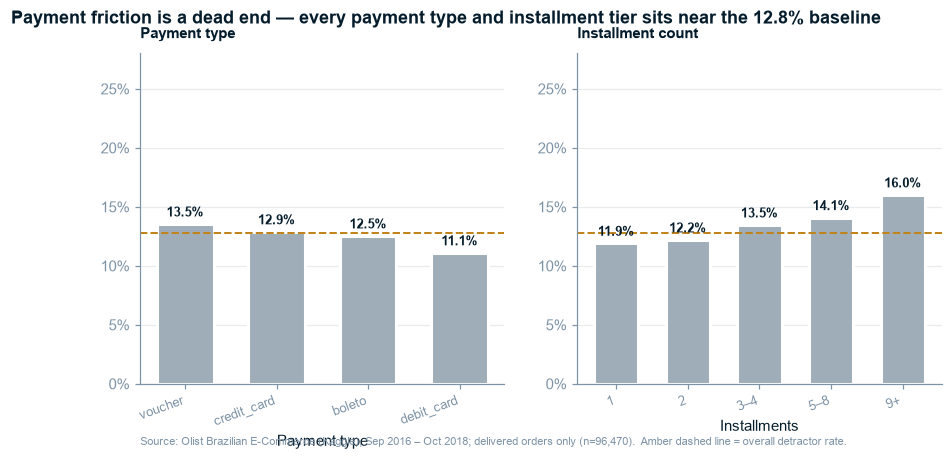

,n,detractor_rate
payment_type,,
voucher,"2,953",13.55%
credit_card,"72,331",12.88%
boleto,"19,062",12.53%
debit_card,"1,477",11.10%


In [11]:
pay_view = (
    rev.groupby("payment_type", observed=True)
    .agg(n=("order_id", "size"), detractor_rate=("is_detractor", "mean"))
    .query("n >= 200").sort_values("detractor_rate", ascending=False)
)
inst_view = (
    rev.assign(inst_bucket=pd.cut(rev.max_installments, [0, 1, 2, 4, 8, 24],
                                  labels=["1", "2", "3–4", "5–8", "9+"]))
    .groupby("inst_bucket", observed=True)
    .agg(n=("order_id", "size"), detractor_rate=("is_detractor", "mean"))
)

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.9))
for ax, data, xlabel, title in [
    (axes[0], pay_view, "Payment type", "Payment type"),
    (axes[1], inst_view, "Installments", "Installment count"),
]:
    b = ax.bar(range(len(data)), data.detractor_rate.values, color=mck.CONTEXT, width=0.62)
    mck.bar_gap_edges(b)
    mck.direct_label(ax, range(len(data)), data.detractor_rate.values,
                     [f"{v:.1%}" for v in data.detractor_rate.values], dy=0.004, size=8.5)
    ax.axhline(rev.is_detractor.mean(), color=mck.REFERENCE, lw=1.3, ls="--")
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels([str(i) for i in data.index], fontsize=8.5, rotation=20, ha="right")
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, 0.28)
    mck.pct_axis(ax)
    ax.set_title(title, fontsize=10)

fig.suptitle("Payment friction is a dead end — every payment type and installment tier sits near the 12.8% baseline",
             x=0.0, ha="left", fontsize=11.5, fontweight="bold", color=mck.NAVY)
mck.source_note(axes[0], f"{SOURCE_DLV}  Amber dashed line = overall detractor rate.")
mck.save(fig, FIGS / "ex09_payment.png", close=False)
plt.show()

display(pay_view.style.format({"detractor_rate": "{:.2%}", "n": "{:,}"}))

> **So What:** the spread across payment types and installment tiers is a few percentage points
> around the 12.8% baseline — **negligible next to the 53-point gap between late and on-time
> orders**.
>
> **Implication:** branch D's payment sub-branch is **closed**. This is reported rather than
> quietly dropped, because a null result on a plausible hypothesis is information: it tells the
> stakeholder not to spend budget on checkout/payment UX in pursuit of satisfaction. Given
> n≈96,000, some of these differences will be statistically significant — which is exactly why
> `04_analysis` reports effect sizes and not just p-values.

## EX 10 — Freight ratio and basket complexity add little beyond distance

**Branch:** B

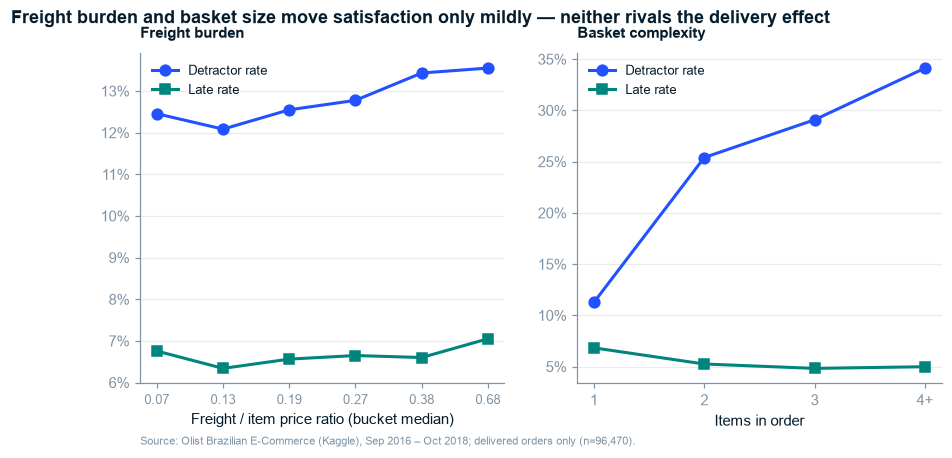

,detractor,late,med_ratio,n
fr_bucket,,,,
0,12.5%,6.8%,0.07,"15,971"
1,12.1%,6.3%,0.13,"15,980"
2,12.5%,6.6%,0.19,"15,971"
3,12.8%,6.6%,0.27,"15,961"
4,13.4%,6.6%,0.38,"15,970"
5,13.5%,7.1%,0.68,"15,971"


In [12]:
rev_fr = rev[rev.freight_ratio.notna() & np.isfinite(rev.freight_ratio)].copy()
rev_fr["fr_bucket"] = pd.qcut(rev_fr.freight_ratio, 6, labels=False, duplicates="drop")
fr_view = rev_fr.groupby("fr_bucket").agg(
    detractor=("is_detractor", "mean"), late=("is_late", "mean"),
    med_ratio=("freight_ratio", "median"), n=("order_id", "size"))

items_view = (
    rev.assign(items_b=pd.cut(rev.n_items, [0, 1, 2, 3, 100], labels=["1", "2", "3", "4+"]))
    .groupby("items_b", observed=True)
    .agg(detractor=("is_detractor", "mean"), late=("is_late", "mean"), n=("order_id", "size"))
)

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.9))
x = range(len(fr_view))
axes[0].plot(x, fr_view.detractor, "-o", color=mck.EMPHASIS, ms=7, label="Detractor rate")
axes[0].plot(x, fr_view.late, "-s", color=mck.COMPARISON, ms=6, label="Late rate")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([f"{v:.2f}" for v in fr_view.med_ratio], fontsize=8.5)
axes[0].set_xlabel("Freight / item price ratio (bucket median)")
axes[0].legend(fontsize=8.5)
axes[0].set_title("Freight burden", fontsize=10)
mck.pct_axis(axes[0])

xi = range(len(items_view))
axes[1].plot(xi, items_view.detractor, "-o", color=mck.EMPHASIS, ms=7, label="Detractor rate")
axes[1].plot(xi, items_view.late, "-s", color=mck.COMPARISON, ms=6, label="Late rate")
axes[1].set_xticks(list(xi)); axes[1].set_xticklabels(items_view.index)
axes[1].set_xlabel("Items in order")
axes[1].legend(fontsize=8.5)
axes[1].set_title("Basket complexity", fontsize=10)
mck.pct_axis(axes[1])

fig.suptitle("Freight burden and basket size move satisfaction only mildly — neither rivals the delivery effect",
             x=0.0, ha="left", fontsize=11.5, fontweight="bold", color=mck.NAVY)
mck.source_note(axes[0], f"{SOURCE_DLV}")
mck.save(fig, FIGS / "ex10_freight_basket.png", close=False)
plt.show()

display(fr_view.style.format({"detractor": "{:.1%}", "late": "{:.1%}", "med_ratio": "{:.2f}", "n": "{:,}"}))

> **So What:** customers paying proportionally more freight are somewhat more likely to be
> detractors, and multi-item orders are late slightly more often (more sellers, more ways to slip).
> Both effects are modest.
>
> **Implication:** these are **secondary risk factors** worth including as model features, not
> standalone levers. No recommendation should rest on them.

## EX 11 — Geography compounds: the North and Northeast wait longest and rate lowest

**Branch:** B · *Sets up the fairness audit*

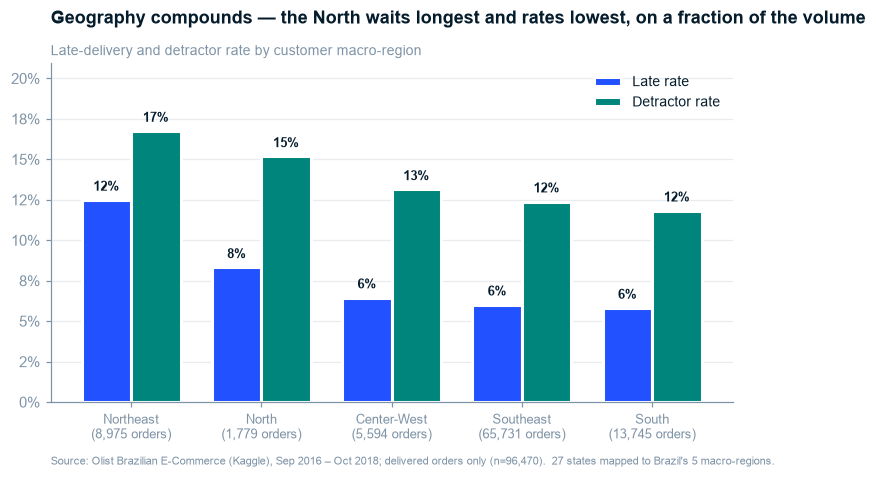

,orders,late,detractor,days
customer_region,,,,
Northeast,"8,975",12.49%,16.75%,19.9
North,"1,779",8.32%,15.18%,22.5
Center-West,"5,594",6.45%,13.14%,15.0
Southeast,"65,731",6.01%,12.38%,10.7
South,"13,745",5.81%,11.82%,14.0


In [13]:
region_view = (
    rev.groupby("customer_region", observed=True)
    .agg(orders=("order_id", "size"), late=("is_late", "mean"),
         detractor=("is_detractor", "mean"), days=("delivery_days", "mean"))
    .sort_values("late", ascending=False)
)

fig, ax = plt.subplots(figsize=(8.0, 4.0))
xr = np.arange(len(region_view))
w = 0.38
b1 = ax.bar(xr - w/2, region_view.late, w, color=mck.EMPHASIS, label="Late rate")
b2 = ax.bar(xr + w/2, region_view.detractor, w, color=mck.COMPARISON, label="Detractor rate")
mck.bar_gap_edges(list(b1) + list(b2))
mck.direct_label(ax, xr - w/2, region_view.late, [f"{v:.0%}" for v in region_view.late], dy=0.004, size=8.5)
mck.direct_label(ax, xr + w/2, region_view.detractor, [f"{v:.0%}" for v in region_view.detractor], dy=0.004, size=8.5)

ax.set_xticks(xr)
ax.set_xticklabels([f"{i}\n({int(n):,} orders)" for i, n in
                    zip(region_view.index, region_view.orders)], fontsize=8.5)
ax.legend(fontsize=9)
ax.set_title("Geography compounds — the North waits longest and rates lowest, on a fraction of the volume")
mck.subtitle(ax, "Late-delivery and detractor rate by customer macro-region")
mck.pct_axis(ax)
ax.set_ylim(0, max(region_view.late.max(), region_view.detractor.max()) * 1.25)
mck.source_note(ax, f"{SOURCE_DLV}  27 states mapped to Brazil's 5 macro-regions.")
mck.save(fig, FIGS / "ex11_region.png", close=False)
plt.show()

display(region_view.style.format({"late": "{:.2%}", "detractor": "{:.2%}",
                                  "days": "{:.1f}", "orders": "{:,}"}))

> **So What:** the North and Northeast experience roughly double the Southeast's late rate and wait
> ~50–80% longer, while the Southeast (SP alone ≈42% of customers) carries the overwhelming
> majority of volume.
>
> **Implication:** this is both a commercial finding and an **ethics flag**. A model that ranks
> risk without controlling for geography will simply rediscover "the North is far away" and push
> operations to deprioritise the regions already receiving the worst service — entrenching the
> disparity. The fairness audit in `04_analysis` tests for exactly this, and the targeting list is
> built on distance-adjusted, seller-controllable defect for that reason.

## EX 12 — The review corpus is a sample of angry customers, not of customers

**Branch:** text · **Mandatory caveat before any text finding**

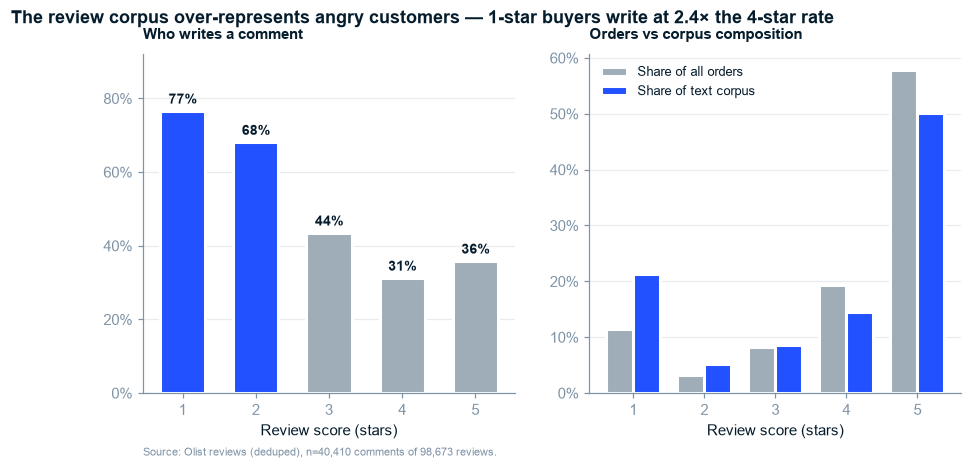

,orders,with_comment,comment_rate,share_of_corpus,share_of_orders
review_score,,,,,
1,"11,363","8,706",76.6%,21.4%,11.5%
2,"3,131","2,133",68.1%,5.2%,3.2%
3,"8,133","3,538",43.5%,8.7%,8.2%
4,"19,038","5,949",31.2%,14.6%,19.3%
5,"57,008","20,449",35.9%,50.2%,57.8%


In [14]:
prop = pd.read_csv(PROCESSED / "_comment_propensity.csv", index_col=0)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0))
ax = axes[0]
cols = [mck.EMPHASIS if s <= 2 else mck.CONTEXT for s in prop.index]
b = ax.bar(prop.index, prop.comment_rate, color=cols, width=0.62)
mck.bar_gap_edges(b)
mck.direct_label(ax, prop.index, prop.comment_rate,
                 [f"{v:.0%}" for v in prop.comment_rate], dy=0.012)
ax.set_xlabel("Review score (stars)"); ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(0, 0.92); mck.pct_axis(ax)
ax.set_title("Who writes a comment", fontsize=10)

ax = axes[1]
w = 0.38
xr = np.arange(len(prop))
b1 = ax.bar(xr - w/2, prop.share_of_orders, w, color=mck.CONTEXT, label="Share of all orders")
b2 = ax.bar(xr + w/2, prop.share_of_corpus, w, color=mck.EMPHASIS, label="Share of text corpus")
mck.bar_gap_edges(list(b1) + list(b2))
ax.set_xticks(xr); ax.set_xticklabels(prop.index)
ax.set_xlabel("Review score (stars)")
ax.legend(fontsize=8.5); mck.pct_axis(ax)
ax.set_title("Orders vs corpus composition", fontsize=10)

fig.suptitle("The review corpus over-represents angry customers — 1-star buyers write at 2.4× the 4-star rate",
             x=0.0, ha="left", fontsize=11.5, fontweight="bold", color=mck.NAVY)
mck.source_note(axes[0], f"Source: Olist reviews (deduped), n={len(corpus):,} comments of {int(prop.orders.sum()):,} reviews.")
mck.save(fig, FIGS / "ex12_comment_bias.png", close=False)
plt.show()

display(prop.style.format({"comment_rate": "{:.1%}", "share_of_corpus": "{:.1%}",
                           "share_of_orders": "{:.1%}", "orders": "{:,}", "with_comment": "{:,}"}))

> **So What:** only **41%** of reviews carry a written comment, and the propensity to write is
> strongly tied to the score — 76.5% of 1-star reviewers write, versus 31% of 4-star. The corpus
> over-represents 1-star customers by roughly 2.4×.
>
> **Implication:** **no raw share of the corpus may be reported as a share of customers.** Doing so
> would overstate dissatisfaction dramatically. Every text-derived rate in `05_text_analysis` is
> either reported *within a score band* or reweighted by inverse comment-propensity, and this
> caveat travels with the text exhibits into the final report rather than living in an appendix.

## Ghost deck — revised after EDA

STRUCTURE.md requires the storyboard be updated once the data has spoken. Changes from the
Stage 0 draft:

| Ghost deck slide | Status after EDA | Change |
|---|---|---|
| EX 1 — cliff not slope | ✅ **Confirmed** | Stands as drafted |
| EX 2 — late → detractor | ✅ **Confirmed, larger than expected** | Hypothesised "several-fold"; actual **6.7×** |
| EX 3 — dose-response | ✅ **Confirmed + refined** | Monotonic, saturating ~80%. New sub-finding: *arriving early buys nothing* |
| EX 4 — seller Pareto | ✅ **Confirmed** | Worst 20% carry **69%** of late orders — stronger than anticipated |
| EX 5 — distance explains lateness | ⚠️ **Downgraded** | Real but modest (4%→9%). Demoted from Key Line to supporting evidence |
| EX 6 — estimate miscalibrated | ✅ **Confirmed, and more interesting** | 12-day median cushion — a commercial lever, not just an ops defect |
| EX 7 — predictive model | ⏭️ Pending `04_analysis` | — |
| **NEW — on-time detractors** | 🆕 **Added, and it reframes the report** | **68% of detractors were delivered on time.** Not anticipated at Stage 0 |
| EX 8–10 — text adjudication | ⏭️ Pending `05_text_analysis` | Now *load-bearing*, not corroboration — it is the only instrument that can explain on-time detractors |

**Revised Governing Thought (draft):** *Dissatisfaction has two distinct causes with two different
owners — a severe but narrow delivery-execution failure concentrated in a minority of sellers, and
a larger, quieter product-experience failure that arrives perfectly on time.*

### Data issues found during EDA → looped back to Stage 2

| Issue | Resolution |
|---|---|
| Late rate computed 8.11% vs documented 6.8% | **Fixed in `02_cleaning`** — lateness now measured at calendar-date granularity, not raw timestamp subtraction. Reproduces 6.77%. |
| `has_voucher` object dtype broke boolean masks | Fixed in `02_cleaning` — cast at source |
| Translation CSV carries a UTF-8 BOM under latin-1 read | Fixed in `02_cleaning` — BOM stripped from all headers on load |

## Stage 3 — Gate Checklist

- [x] **Automated profiling generated and reviewed** — §3.0 (targeted equivalent; `ydata-profiling` unavailable)
- [x] **Each Stage 0 hypothesis has ≥1 corresponding analysis** — all four branches covered; branch D's payment sub-branch returned a **documented null**
- [x] **Key distributions and relationships visualised and annotated** — 12 exhibits
- [x] **All chart titles are Action Titles** — every title states the insight
- [x] **Every finding has a "So What?" and "Implication"** — written beneath each exhibit
- [x] **Ghost deck updated** — above, with two downgrades and one material addition
- [x] **Data issues logged and addressed** — 3 found, all looped back to Stage 2 and fixed
- [x] **Preliminary findings documented** — revised Governing Thought drafted
- [x] **Palette validated, not eyeballed** — `validate_palette.js` run; Slate removed from the
      categorical set after it failed normal-vision separation against Cyan (see `src/mck_style.py`)

**Gate status: PASSED** → proceed to `04_analysis.ipynb`.

In [15]:
key_eda = {
    "n_orders_total": int(len(abt)),
    "n_delivered": int(len(dlv)),
    "n_reviewed": int(len(rev)),
    "late_rate": float(dlv.is_late.mean()),
    "detractor_rate": float(rev.is_detractor.mean()),
    "detractor_rate_late": float(rate_late),
    "detractor_rate_ontime": float(rate_ontime),
    "risk_ratio": float(ratio),
    "pct_detractors_ontime": float(n_ontime_det / n_detractors),
    "n_detractors": int(n_detractors),
    "n_detractors_ontime": int(n_ontime_det),
    "seller_pareto_top20_share": float(share_at_20),
    "seller_gini": float(gini),
    "median_days_early": float(-med),
    "mean_estimate_window": float(dlv.estimate_window_days.mean()),
    "mean_actual_delivery": float(dlv.delivery_days.mean()),
    "comment_rate_overall": float(len(corpus) / len(rev)),
    "comment_propensity_ratio": float(prop.comment_rate.loc[1] / prop.comment_rate.loc[4]),
}
pd.Series(key_eda).to_json(ROOT / "reports" / "_key_figures_eda.json", indent=2)
print("Stage 3 complete — 12 exhibits written to reports/figures/")
for k, v in key_eda.items():
    print(f"  {k:28} {v:,.4f}" if isinstance(v, float) else f"  {k:28} {v:,}")

Stage 3 complete — 12 exhibits written to reports/figures/
  n_orders_total               99,441
  n_delivered                  96,470
  n_reviewed                   95,824
  late_rate                    0.0677
  detractor_rate               0.1281
  detractor_rate_late          0.6242
  detractor_rate_ontime        0.0927
  risk_ratio                   6.7354
  pct_detractors_ontime        0.6754
  n_detractors                 12,272
  n_detractors_ontime          8,289
  seller_pareto_top20_share    0.6876
  seller_gini                  0.6574
  median_days_early            12.0000
  mean_estimate_window         23.7363
  mean_actual_delivery         12.5582
  comment_rate_overall         0.4217
  comment_propensity_ratio     2.4519
